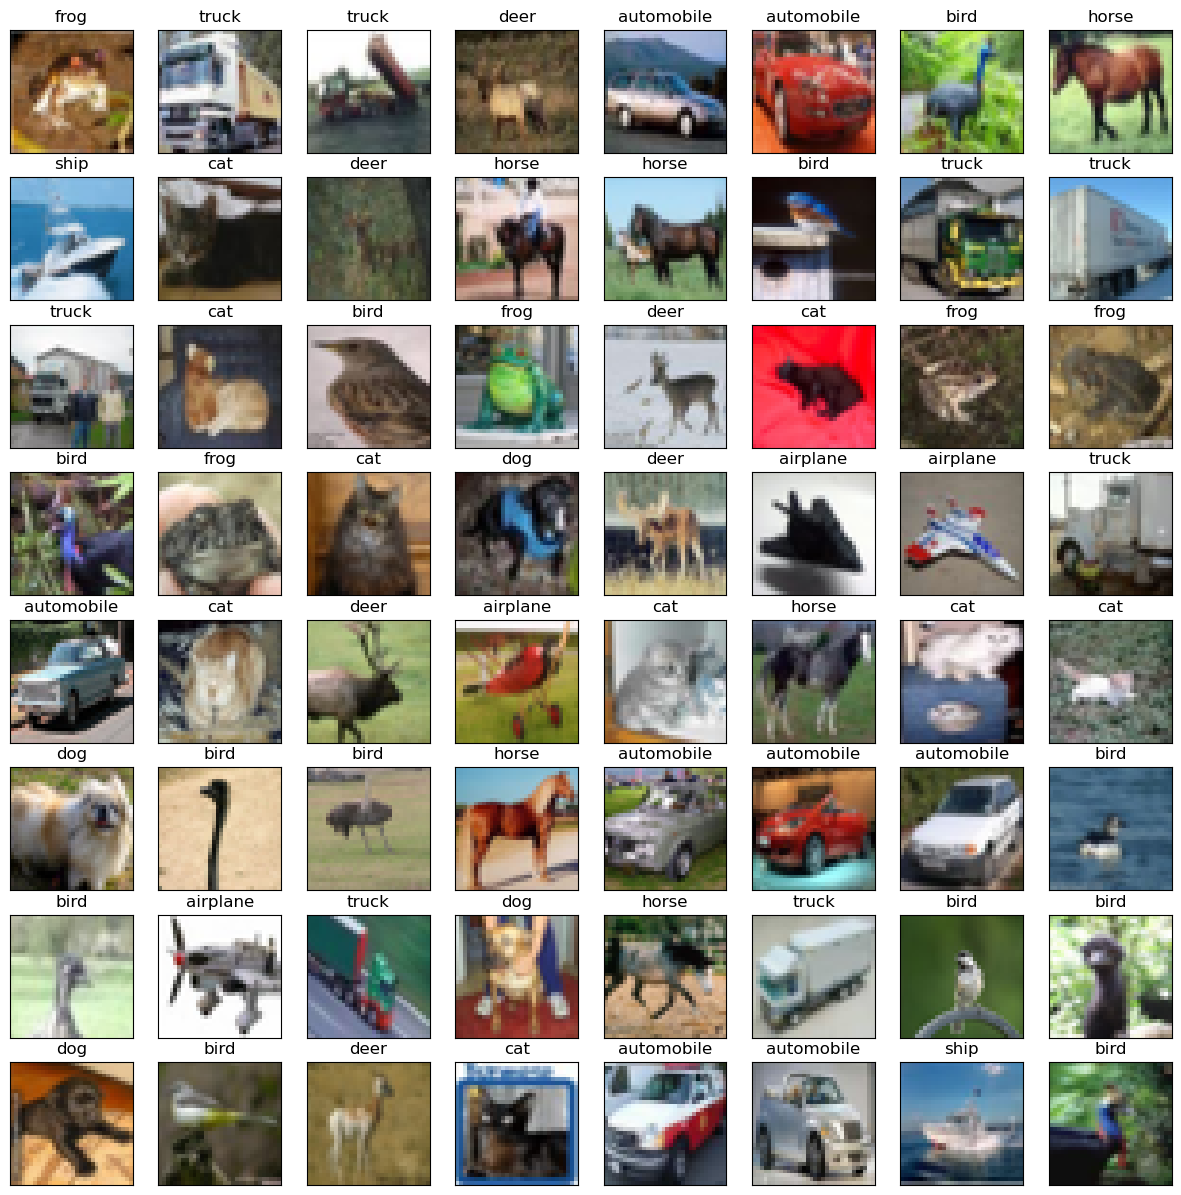

C:\Users\maksn\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
2813/2813 - 61s - 22ms/step - accuracy: 0.3242 - loss: 1.8186 - val_accuracy: 0.4494 - val_loss: 1.5057
Epoch 2/15
2813/2813 - 68s - 24ms/step - accuracy: 0.4793 - loss: 1.4429 - val_accuracy: 0.5620 - val_loss: 1.2164
Epoch 3/15
2813/2813 - 55s - 20ms/step - accuracy: 0.5404 - loss: 1.2932 - val_accuracy: 0.6020 - val_loss: 1.1743
Epoch 4/15
2813/2813 - 48s - 17ms/step - accuracy: 0.5660 - loss: 1.2231 - val_accuracy: 0.6060 - val_loss: 1.1360
Epoch 5/15
2813/2813 - 49s - 18ms/step - accuracy: 0.5862 - loss: 1.1767 - val_accuracy: 0.6298 - val_loss: 1.0483
Epoch 6/15
2813/2813 - 76s - 27ms/step - accuracy: 0.6004 - loss: 1.1458 - val_accuracy: 0.6688 - val_loss: 0.9536
Epoch 7/15
2813/2813 - 83s - 29ms/step - accuracy: 0.6123 - loss: 1.1186 - val_accuracy: 0.6464 - val_loss: 1.0247
Epoch 8/15
2813/2813 - 42s - 15ms/step - accuracy: 0.6112 - loss: 1.1199 - val_accuracy: 0.6718 - val_loss: 0.9616
Epoch 9/15
2813/2813 - 86s - 31ms/step - accuracy: 0.6151 - loss: 1.1149 - val_a

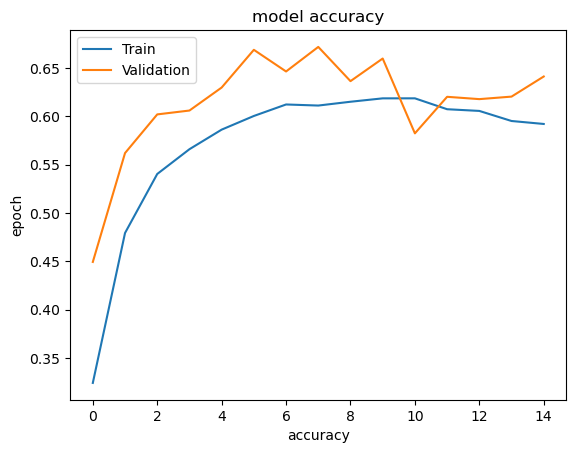

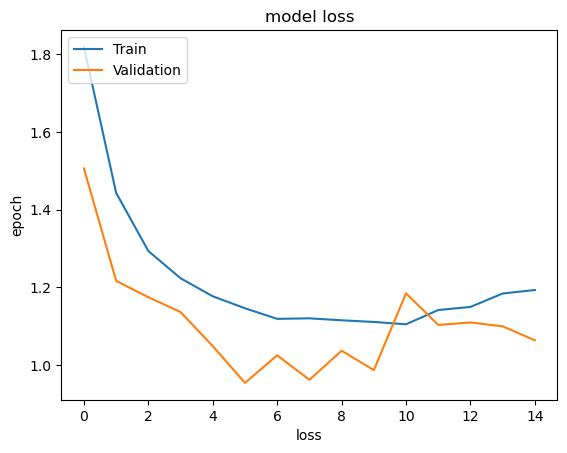

In [1]:
import numpy as np
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Flatten, Activation
from keras.layers import Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from keras.utils import to_categorical
from keras.optimizers import SGD
import matplotlib.pyplot as plt

#seed для повторяемости результатов:
np.random.seed(42)

#данные из набора CIFAR-10:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))
for i in range(64):
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=12)
plt.show()
batch_size = 16

nb_classes = 10

#количество эпох для обучения
nb_epoch = 15

#размер изображений
img_rows, img_cols = 32, 32

#количество каналов в изображении (RGB)
img_channels = 3

#нормализуем данные
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

#Преобразуем метки в категории
Y_train = to_categorical(y_train, nb_classes)
Y_test = to_categorical(y_test, nb_classes)

model = Sequential()

#первый сверточный слой
model.add(Conv2D(32, (3, 3), padding='same',
    input_shape=(32, 32, 3), activation='relu'))
#второй сверточный слой
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))

#первый слой подвыборки
model.add(MaxPooling2D(pool_size=(2, 2)))

#слой регуляции Dropout
model.add(Dropout(0.25))

#третий сверточный слой - ИЗМЕНЕНО 64 - 32
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))

#четвертый сверточный слой
model.add(Conv2D(64, (3, 3), activation='relu'))

#второй слой подвыборки
model.add(MaxPooling2D(pool_size=(2, 2)))

#слой регуляризации Dropout
model.add(Dropout(0.25))

#слой преобразования данных из 2D представления в плоское
model.add(Flatten())
#полносвязный слой для классификации !!! Изменено 512- 1024
model.add(Dense(1024, activation='relu'))
#слой регуляризации Dropout
model.add(Dropout(0.5))
#выходной полносвязный слой
model.add(Dense(nb_classes, activation='softmax'))

#параметры оптимизации
sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

#обучаем модель
history = model.fit(X_train, Y_train,
    batch_size=batch_size,
    epochs=nb_epoch,
    validation_split=0.1,
    shuffle=True,
    verbose=2)

scores = model.evaluate(X_test, Y_test, verbose=0)
print("Точность работы на тестовых данных: %.2f%%" % (scores[1]*100))

#итог history для точности (accuracy)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('accuracy')
plt.ylabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#итог history для потери (loss)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.xlabel('loss')
plt.ylabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()